In [1]:
# Install required packages
!pip install -q medmnist transformers torch pillow accelerate bitsandbytes

In [2]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.9.0+cu128
CUDA available: True


In [3]:
# Cell 3: Load LLaVA-Med
model_id = "microsoft/llava-med-v1.5-mistral-7b"

print("Loading Visual Language Model...")
print("This may take 3-5 minutes...")

processor = AutoProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)

print("✓ Model loaded successfully!")
print(f"Model device: {model.device}")

Loading Visual Language Model...
This may take 3-5 minutes...


You are using a model of type llava_mistral to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
You are using a model of type llava_mistral to instantiate a model of type llava. This is not supported for all configurations of models and can yield errors.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

LlavaForConditionalGeneration LOAD REPORT from: microsoft/llava-med-v1.5-mistral-7b
Key                                                                                            | Status     | 
-----------------------------------------------------------------------------------------------+------------+-
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED | 
model.layers.{0...31}.mlp.down_proj.weight                                                     | UNEXPECTED | 
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED | 
model.layers.{0...31}.self_attn.k_proj.weight                                                  | UNEXPECTED | 
model.layers.{0...31}.post_attention_layernorm.weight                                          | UNEXPECTED | 
model.vision_tower.vision_tower.vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED | 
model.embed_tokens.weight   

✓ Model loaded successfully!
Model device: cuda:0


✓ Custom dataset created
  Total samples: 624
  Classes: 0 = Normal, 1 = Pneumonia

✓ Sample data:
  PIL image size: (224, 224)
  PIL image type: <class 'PIL.Image.Image'>
  Tensor shape: torch.Size([1, 300, 300])
  Label: 1 (Pneumonia)


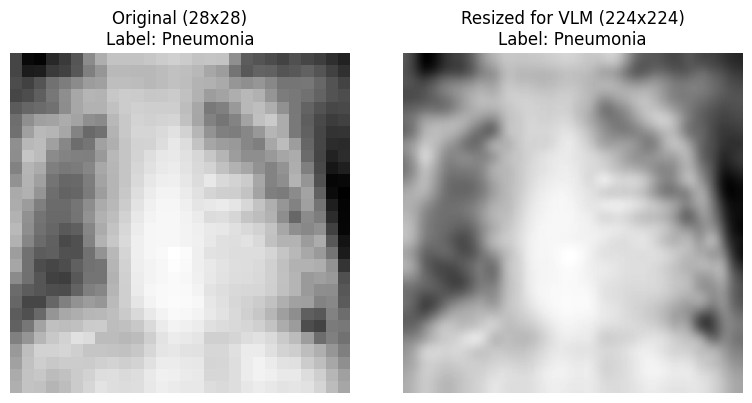

In [4]:
class PneumoniaMNIST_VLM(Dataset):
    """
    Custom Dataset that returns both transformed tensors and PIL images
    """
    def __init__(self, split='test', tensor_transform=None):
        """
        Args:
            split: 'train', 'val', or 'test'
            tensor_transform: Transforms for tensor output (for CNN)
        """
        # Load base dataset WITHOUT transforms
        self.base_dataset = PneumoniaMNIST(split=split, download=True, transform=None)
        self.tensor_transform = tensor_transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # Get image and label from base dataset
        img, label = self.base_dataset[idx]

        # img is already a PIL Image when transform=None
        # Ensure it's grayscale
        if isinstance(img, Image.Image):
            pil_img = img.convert('L')
        else:
            # Fallback: if it's numpy array
            import numpy as np
            if isinstance(img, np.ndarray):
                pil_img = Image.fromarray(img.squeeze(), mode='L')
            else:
                raise TypeError(f"Unexpected image type: {type(img)}")

        # Create tensor version if transform provided
        if self.tensor_transform:
            tensor_img = self.tensor_transform(pil_img)
        else:
            tensor_img = None

        # Resize PIL image to 224x224 for VLM
        pil_img_vlm = pil_img.resize((224, 224), Image.Resampling.LANCZOS)

        # Handle label - could be tensor or int
        if hasattr(label, 'item'):
            label_int = label.item()
        else:
            label_int = int(label)

        return {
            'pil_image': pil_img_vlm,      # For VLM (224x224)
            'tensor_image': tensor_img,     # For CNN (optional)
            'original_pil': pil_img,        # Original size PIL (28x28)
            'label': label_int
        }

# Define transforms for tensor version (matching Task 1)
tensor_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Create dataset
test_dataset = PneumoniaMNIST_VLM(split='test', tensor_transform=tensor_transform)

print(f"✓ Custom dataset created")
print(f"  Total samples: {len(test_dataset)}")
print(f"  Classes: 0 = Normal, 1 = Pneumonia")

# Test the dataset
sample = test_dataset[0]
print(f"\n✓ Sample data:")
print(f"  PIL image size: {sample['pil_image'].size}")
print(f"  PIL image type: {type(sample['pil_image'])}")
print(f"  Tensor shape: {sample['tensor_image'].shape if sample['tensor_image'] is not None else 'None'}")
print(f"  Label: {sample['label']} ({'Pneumonia' if sample['label'] == 1 else 'Normal'})")

# Visualize
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample['original_pil'], cmap='gray')
plt.title(f"Original (28x28)\nLabel: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample['pil_image'], cmap='gray')
plt.title(f"Resized for VLM (224x224)\nLabel: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Different prompting strategies to test
PROMPTS = {
    "basic": "Describe this chest X-ray image.",

    "detailed": """You are an expert radiologist. Analyze this chest X-ray image and provide a detailed report including:
1. Overall image quality
2. Visible anatomical structures
3. Any abnormal findings
4. Impression""",

    "pneumonia_focused": """Analyze this chest X-ray for signs of pneumonia. Report on:
- Lung field clarity
- Presence of infiltrates or consolidation
- Any opacities or abnormal densities
- Overall assessment: Normal or Pneumonia suspected""",

    "structured": """Generate a structured radiology report for this chest X-ray:

FINDINGS:
- Right lung:
- Left lung:
- Heart and mediastinum:

IMPRESSION:""",

    "yes_no": "Does this chest X-ray show signs of pneumonia? Answer Yes or No and explain your reasoning based on the radiological findings.",

    "comparison": """Compare this chest X-ray to a normal chest X-ray. What differences or abnormalities do you observe? Is this normal or abnormal?"""
}

print("Defined 6 different prompting strategies:")
for name in PROMPTS.keys():
    print(f"  - {name}")

Defined 6 different prompting strategies:
  - basic
  - detailed
  - pneumonia_focused
  - structured
  - yes_no
  - comparison


In [6]:
def generate_report(image, prompt, model, processor, max_tokens=250):
    """
    Generate medical report from image using VLM
    """
    model.eval()

    # Conversation format (universal style)
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt}
            ]
        }
    ]

    # Build prompt
    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Prepare inputs
    inputs = processor(
        text=prompt_text,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            eos_token_id=processor.tokenizer.eos_token_id
        )

    # Decode
    full_text = processor.decode(outputs[0], skip_special_tokens=True)

    # Extract assistant answer cleanly
    if "ASSISTANT:" in full_text:
        report = full_text.split("ASSISTANT:")[-1].strip()
    elif "assistant" in full_text.lower():
        report = full_text.split("assistant")[-1].strip(": \n")
    else:
        report = full_text[len(prompt_text):].strip()

    return report


In [7]:
# Upload the .npy files you saved from Task 1
from google.colab import files

print("Please upload your Task 1 output files:")
print("  - task1_test_labels.npy")
print("  - task1_test_predictions.npy")
print("  - task1_test_probabilities.npy (optional)\n")

uploaded = files.upload()

# Load the files
lbls = np.load('task1_test_labels.npy')
prds = np.load('task1_test_predictions.npy')

# If you have probabilities
try:
    probs = np.load('task1_test_probabilities.npy')
    print(f"✓ Loaded probabilities: {probs.shape}")
except:
    probs = None
    print("⚠ Probabilities not loaded (optional)")

print(f"\n✓ Loaded Task 1 outputs:")
print(f"  - Labels: {lbls.shape}")
print(f"  - Predictions: {prds.shape}")

# Verify alignment with test dataset
assert len(lbls) == len(test_dataset), "Label count mismatch!"
assert len(prds) == len(test_dataset), "Prediction count mismatch!"
print(f"\n✓ Verified: {len(lbls)} samples match test dataset size")

Please upload your Task 1 output files:
  - task1_test_labels.npy
  - task1_test_predictions.npy
  - task1_test_probabilities.npy (optional)



Saving task1_test_labels.npy to task1_test_labels (2).npy
Saving task1_test_predictions.npy to task1_test_predictions (2).npy
Saving task1_test_probabilities.npy to task1_test_probabilities (2).npy
✓ Loaded probabilities: (624,)

✓ Loaded Task 1 outputs:
  - Labels: (624,)
  - Predictions: (624,)

✓ Verified: 624 samples match test dataset size


In [8]:
# Select samples based on CNN performance
print("Selecting diverse sample images based on CNN results...")

# Find different categories
normal_correct = np.where((lbls == 0) & (prds == 0))[0]  # True Negatives
pneumonia_correct = np.where((lbls == 1) & (prds == 1))[0]  # True Positives
false_positives = np.where((lbls == 0) & (prds == 1))[0]  # Normal → Pneumonia
false_negatives = np.where((lbls == 1) & (prds == 0))[0]  # Pneumonia → Normal

print(f"\nCNN Performance Breakdown:")
print(f"  ✓ Normal (Correct):     {len(normal_correct)} cases")
print(f"  ✓ Pneumonia (Correct):  {len(pneumonia_correct)} cases")
print(f"  ✗ False Positives:      {len(false_positives)} cases")
print(f"  ✗ False Negatives:      {len(false_negatives)} cases")

# Select diverse samples (at least 10 images)
np.random.seed(42)

selected_indices = []

# 3 normal correct predictions
if len(normal_correct) >= 3:
    selected_indices.extend(np.random.choice(normal_correct, 3, replace=False))

# 3 pneumonia correct predictions
if len(pneumonia_correct) >= 3:
    selected_indices.extend(np.random.choice(pneumonia_correct, 3, replace=False))

# 2 false positives (if available)
if len(false_positives) >= 2:
    selected_indices.extend(np.random.choice(false_positives, 2, replace=False))
elif len(false_positives) > 0:
    selected_indices.extend(false_positives)

# 2 false negatives (if available)
if len(false_negatives) >= 2:
    selected_indices.extend(np.random.choice(false_negatives, 2, replace=False))
elif len(false_negatives) > 0:
    selected_indices.extend(false_negatives)

sample_indices = np.array(selected_indices)

print(f"\n✓ Selected {len(sample_indices)} diverse samples:")
print(f"  Sample indices: {sample_indices}")

Selecting diverse sample images based on CNN results...

CNN Performance Breakdown:
  ✓ Normal (Correct):     158 cases
  ✓ Pneumonia (Correct):  387 cases
  ✗ False Positives:      76 cases
  ✗ False Negatives:      3 cases

✓ Selected 10 diverse samples:
  Sample indices: [487 164 514 227 562 295 147 107 533 381]


In [9]:
def generate_report(image, prompt, model, processor, max_tokens=250):
    """
    Generate medical report from image using VLM

    Args:
        image: PIL Image
        prompt: Text prompt
        model: VLM model
        processor: Image/text processor
        max_tokens: Maximum tokens to generate

    Returns:
        Generated text report
    """
    # Simple prompt format for LLaVA-Med
    prompt_text = f"USER: <image>\n{prompt}\nASSISTANT:"

    # Process inputs
    inputs = processor(text=prompt_text, images=image, return_tensors="pt").to(model.device)

    # Generate response
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False
        )

    # Decode output
    generated_text = processor.decode(output[0], skip_special_tokens=True)

    # Extract assistant's response (everything after "ASSISTANT:")
    if "ASSISTANT:" in generated_text:
        report = generated_text.split("ASSISTANT:")[-1].strip()
    else:
        report = generated_text.strip()

    return report

# Test on one image
print("Testing report generation...")
sample = test_dataset[0]
test_report = generate_report(sample['pil_image'], PROMPTS["pneumonia_focused"], model, processor)

print(f"\nGround Truth: {'Pneumonia' if sample['label'] == 1 else 'Normal'}")
print(f"\n{'='*60}")
print("GENERATED REPORT:")
print('='*60)
print(test_report)
print('='*60)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing report generation...

Ground Truth: Pneumonia

GENERATED REPORT:
US ER : < im age > An aly ze th is ch est X - ray for sig ns of p ne um on ia . Re port on : - Lu ng field cl ar ity - Pr es en ce of in fil tr at es or co ns ol id at ion - Any op ac it ies or ab no rm al de ns it ies - Over all ass ess ment : No rm al or P ne um on ia su sp ect ed AS SI ST ANT : rile TM ▁Cer hd erna nero ▁Angeles heim ▁Fut ubre borg bars arl ▁overhead camp isti amon ▁otherwise ▁Roman ▁advers ▁reveal uspend iejsc oun ▁Car ▁/******/ ред fol nor refix ▁Ton ▁miles ▁Pent Views agnost ▁Tall дя ▁/******/ porte aban rieg ▁tick arden ilton ▁/******/ ▁sustained Ź ippi ahn ▁prim gency ▁kin ales ▁dual vir ners efore <0xA1> apis ech ▁acknow ilor rezent elte ▁Gem tera ▁Rail RV ▁Krieg ema aurus rael impse ingo ▁protecting <0xA3> lass ugno igo sten las ▁war iaz hren ▁Cry lick ▁Kenn lette mixer aupt <0x88> ahren alen rena <0x86> esk ieb asz ppo imer af <0xAF> resse iman ache ois ▁/******/ isti imo aille rous izi

In [10]:
# Test all prompting strategies on a few images
print("Testing all prompting strategies on 3 sample images...\n")

prompt_comparison_results = []

for idx in sample_indices[:3]:  # Just 3 images to save time
    sample = test_dataset[int(idx)]

    comparison_result = {
        'index': int(idx),
        'ground_truth': 'Pneumonia' if sample['label'] == 1 else 'Normal',
        'pil_image': sample['pil_image'],
        'prompt_reports': {}
    }

    print(f"Image {idx} (Ground Truth: {comparison_result['ground_truth']})")

    for prompt_name, prompt_text in PROMPTS.items():
        print(f"  Generating with '{prompt_name}' prompt...")
        report = generate_report(sample['pil_image'], prompt_text, model, processor)
        comparison_result['prompt_reports'][prompt_name] = report

    prompt_comparison_results.append(comparison_result)
    print()

print("✓ Prompting strategy comparison complete!")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Testing all prompting strategies on 3 sample images...

Image 487 (Ground Truth: Normal)
  Generating with 'basic' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'detailed' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

  Generating with 'structured' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'yes_no' prompt...


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


  Generating with 'comparison' prompt...

✓ Prompting strategy comparison complete!


In [12]:
print("Generating reports for all sample images...")
print("This will take 5-10 minutes...\n")

results = []

for idx in tqdm(sample_indices, desc="Processing images"):
    idx = int(idx)
    sample = test_dataset[idx]

    sample_result = {
        'index': idx,
        'ground_truth': 'Pneumonia' if sample['label'] == 1 else 'Normal',
        'cnn_prediction': 'Pneumonia' if prds[idx] == 1 else 'Normal',
        'cnn_correct': bool(lbls[idx] == prds[idx]),
        'pil_image': sample['pil_image'],
        'reports': {}
    }

    # Add probability if available
    if probs is not None:
        sample_result['cnn_confidence'] = float(probs[idx])

    # Generate report
    try:
        report = generate_report(sample['pil_image'], PROMPTS["pneumonia_focused"], model, processor)
        sample_result['reports']['pneumonia_focused'] = report
    except Exception as e:
        print(f"\nError on image {idx}: {str(e)}")
        sample_result['reports']['pneumonia_focused'] = f"ERROR: {str(e)}"

    results.append(sample_result)

    # Clear cache periodically
    if (len(results) % 3 == 0):
        torch.cuda.empty_cache()

print(f"\n✓ Generated {len(results)} reports successfully!")

Generating reports for all sample images...
This will take 5-10 minutes...



Processing images: 100%|██████████| 10/10 [09:12<00:00, 55.29s/it]


✓ Generated 10 reports successfully!


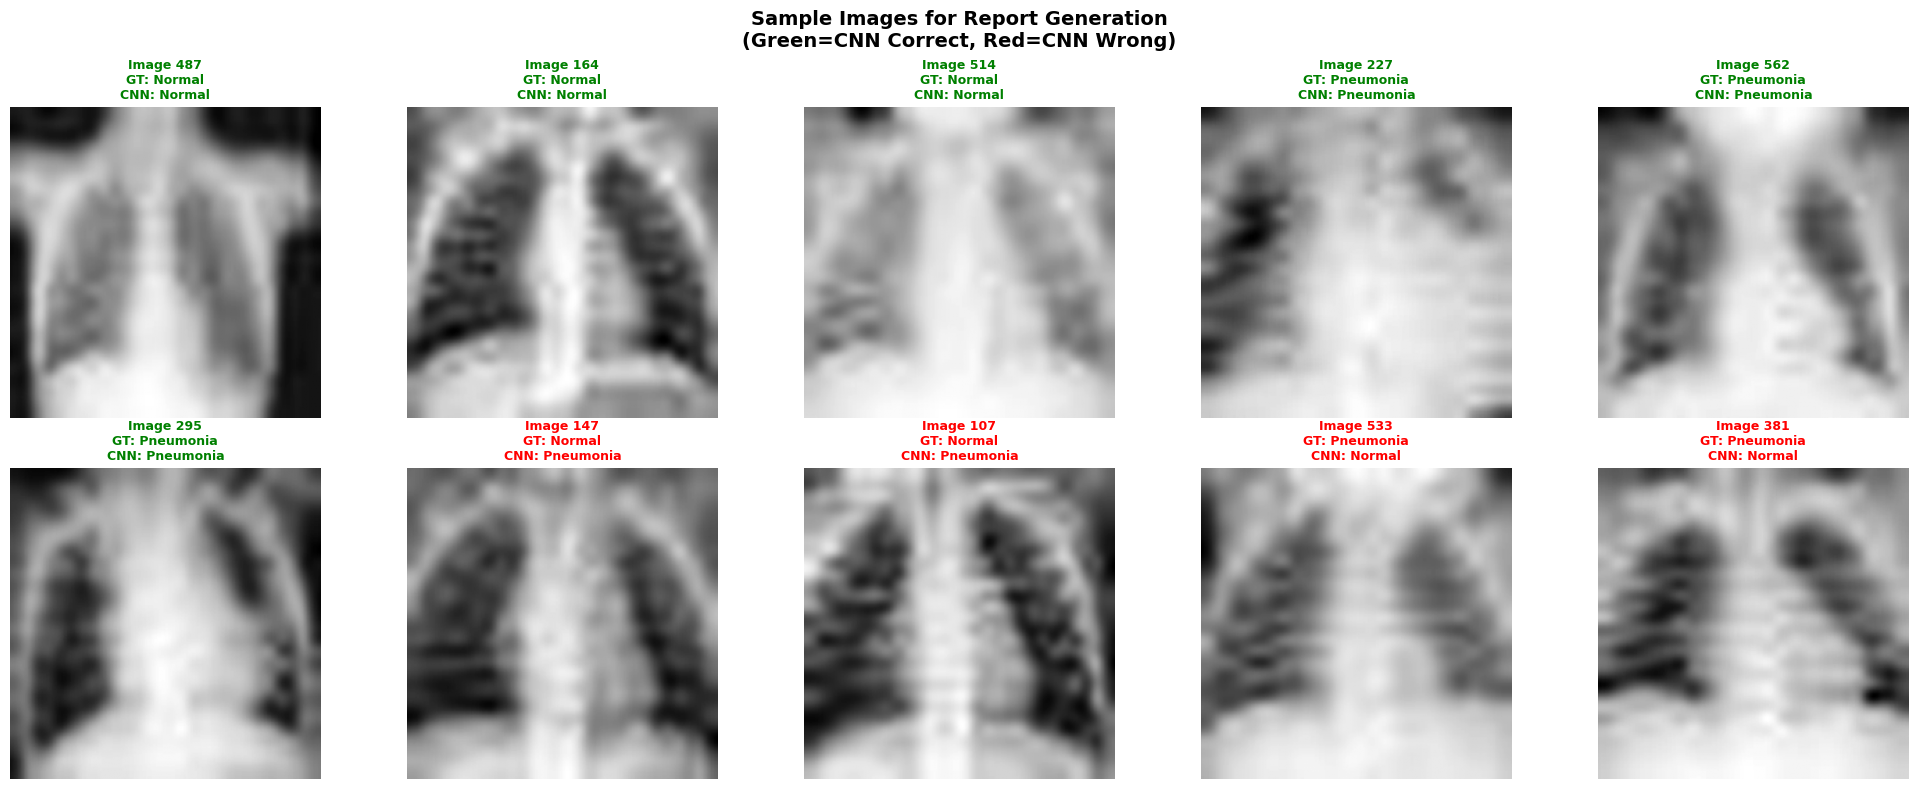

In [13]:
# Visualize all sample images with CNN predictions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(min(10, len(results))):
    result = results[i]
    axes[i].imshow(result['pil_image'], cmap='gray')

    # Color code: green if CNN correct, red if wrong
    color = 'green' if result['cnn_correct'] else 'red'

    title = f"Image {result['index']}\n"
    title += f"GT: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"

    axes[i].set_title(title, fontsize=9, fontweight='bold', color=color)
    axes[i].axis('off')

# Hide extra subplots if less than 10 images
for i in range(len(results), 10):
    axes[i].axis('off')

plt.suptitle('Sample Images for Report Generation\n(Green=CNN Correct, Red=CNN Wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Compare different prompting strategies for one image
if len(prompt_comparison_results) > 0:
    sample_idx = 0
    comparison = prompt_comparison_results[sample_idx]

    print("="*80)
    print(f"PROMPTING STRATEGY COMPARISON - Image {comparison['index']}")
    print(f"Ground Truth: {comparison['ground_truth']}")
    print("="*80)

    for prompt_name, report in comparison['prompt_reports'].items():
        print(f"\n{'─'*80}")
        print(f"PROMPT: {prompt_name.upper()}")
        print('─'*80)
        print(report[:500])  # Truncate if very long
        if len(report) > 500:
            print("... (truncated)")
        print()
else:
    print("No prompt comparison results available.")

PROMPTING STRATEGY COMPARISON - Image 487
Ground Truth: Normal

────────────────────────────────────────────────────────────────────────────────
PROMPT: BASIC
────────────────────────────────────────────────────────────────────────────────
US ER : < im age > Des cri be th is ch est X - ray im age . AS SI ST ANT : <0x82> plain ▁/******/ ▁Ped MX št <0x8A> MX ▁ra lage chat vern ▁Nort cks acs iam ▁/******/ cean orer rub ▁partially aca plot ▁bon iber ▁Tay ▁Rap ▁nowhere tagon SR ▁/******/ enu ▁/******/ ▁afford asm yers hem lio igd ▁Cache igne rale ▁Fra rou onne ńst ▁/******/ enson eden esser ▁resid itr ñ ▁brass ▁proxim MT oba inski uld ieck ▁/******/ iew ▁signs ▁tick olean ▁Jac zb anst occ ▁OR ye raf ▁packed arden ▁fu MB ▁serv igne ▁Cro
... (truncated)


────────────────────────────────────────────────────────────────────────────────
PROMPT: DETAILED
────────────────────────────────────────────────────────────────────────────────
US ER : < im age > You are an ex pert rad io log ist . An aly 

In [16]:
# Enhanced analysis: Compare VLM with both Ground Truth and CNN
print("="*80)
print("COMPREHENSIVE ANALYSIS: VLM vs Ground Truth vs CNN")
print("="*80)

analysis_results = []

for result in results:
    report_text = result['reports']['pneumonia_focused'].lower()

    # Check for pneumonia-related keywords
    pneumonia_keywords = ['pneumonia', 'infiltrate', 'consolidation', 'opacity', 'opacities', 'abnormal']
    normal_keywords = ['normal', 'clear', 'no abnormal', 'unremarkable', 'no evidence']

    mentions_pneumonia = any(keyword in report_text for keyword in pneumonia_keywords)
    mentions_normal = any(keyword in report_text for keyword in normal_keywords)

    # Determine VLM assessment
    if mentions_pneumonia and not mentions_normal:
        vlm_assessment = 'Pneumonia'
    elif mentions_normal and not mentions_pneumonia:
        vlm_assessment = 'Normal'
    elif mentions_pneumonia and mentions_normal:
        # Both mentioned - look for negations
        if 'no pneumonia' in report_text or 'no infiltrate' in report_text:
            vlm_assessment = 'Normal'
        else:
            vlm_assessment = 'Unclear'
    else:
        vlm_assessment = 'Unclear'

    vlm_agrees_gt = (vlm_assessment == result['ground_truth'])
    vlm_agrees_cnn = (vlm_assessment == result['cnn_prediction'])

    analysis_results.append({
        'index': result['index'],
        'ground_truth': result['ground_truth'],
        'cnn_prediction': result['cnn_prediction'],
        'vlm_assessment': vlm_assessment,
        'vlm_agrees_gt': vlm_agrees_gt,
        'vlm_agrees_cnn': vlm_agrees_cnn,
        'cnn_correct': result['cnn_correct']
    })

    # Status indicators
    gt_status = "✓" if vlm_agrees_gt else "✗"
    cnn_status = "✓" if vlm_agrees_cnn else "✗"
    cnn_acc = "✓" if result['cnn_correct'] else "✗"

    print(f"Image {result['index']:3d}: GT={result['ground_truth']:9s} | "
          f"CNN={result['cnn_prediction']:9s}{cnn_acc} | "
          f"VLM={vlm_assessment:9s} | "
          f"VLM-GT:{gt_status} VLM-CNN:{cnn_status}")

# Calculate statistics
vlm_gt_agreement = sum(1 for r in analysis_results if r['vlm_agrees_gt'])
vlm_cnn_agreement = sum(1 for r in analysis_results if r['vlm_agrees_cnn'])
cnn_accuracy = sum(1 for r in analysis_results if r['cnn_correct'])

print(f"\n{'='*80}")
print(f"SUMMARY STATISTICS:")
print(f"  CNN Accuracy:            {cnn_accuracy}/{len(results)} ({cnn_accuracy/len(results)*100:.1f}%)")
print(f"  VLM-Ground Truth Match:  {vlm_gt_agreement}/{len(results)} ({vlm_gt_agreement/len(results)*100:.1f}%)")
print(f"  VLM-CNN Agreement:       {vlm_cnn_agreement}/{len(results)} ({vlm_cnn_agreement/len(results)*100:.1f}%)")
print('='*80)

# Interesting cases: Where VLM disagrees with CNN but agrees with GT
vlm_catches_cnn_errors = [r for r in analysis_results
                          if not r['cnn_correct'] and r['vlm_agrees_gt']]

if vlm_catches_cnn_errors:
    print(f"\n🔍 INTERESTING: VLM caught {len(vlm_catches_cnn_errors)} CNN errors!")
    for case in vlm_catches_cnn_errors:
        print(f"  Image {case['index']}: GT={case['ground_truth']}, "
              f"CNN={case['cnn_prediction']} (wrong), VLM={case['vlm_assessment']} (correct!)")
else:
    print("\n⚠ VLM did not catch any CNN errors in this sample.")

COMPREHENSIVE ANALYSIS: VLM vs Ground Truth vs CNN
Image 487: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 164: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 514: GT=Normal    | CNN=Normal   ✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 227: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 562: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 295: GT=Pneumonia | CNN=Pneumonia✓ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 147: GT=Normal    | CNN=Pneumonia✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 107: GT=Normal    | CNN=Pneumonia✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 533: GT=Pneumonia | CNN=Normal   ✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗
Image 381: GT=Pneumonia | CNN=Normal   ✗ | VLM=Unclear   | VLM-GT:✗ VLM-CNN:✗

SUMMARY STATISTICS:
  CNN Accuracy:            6/10 (60.0%)
  VLM-Ground Truth Match:  0/10 (0.0%)
  VLM-CNN Agreement:       0/10 (0.0%)

⚠ VLM did not catch any CNN e

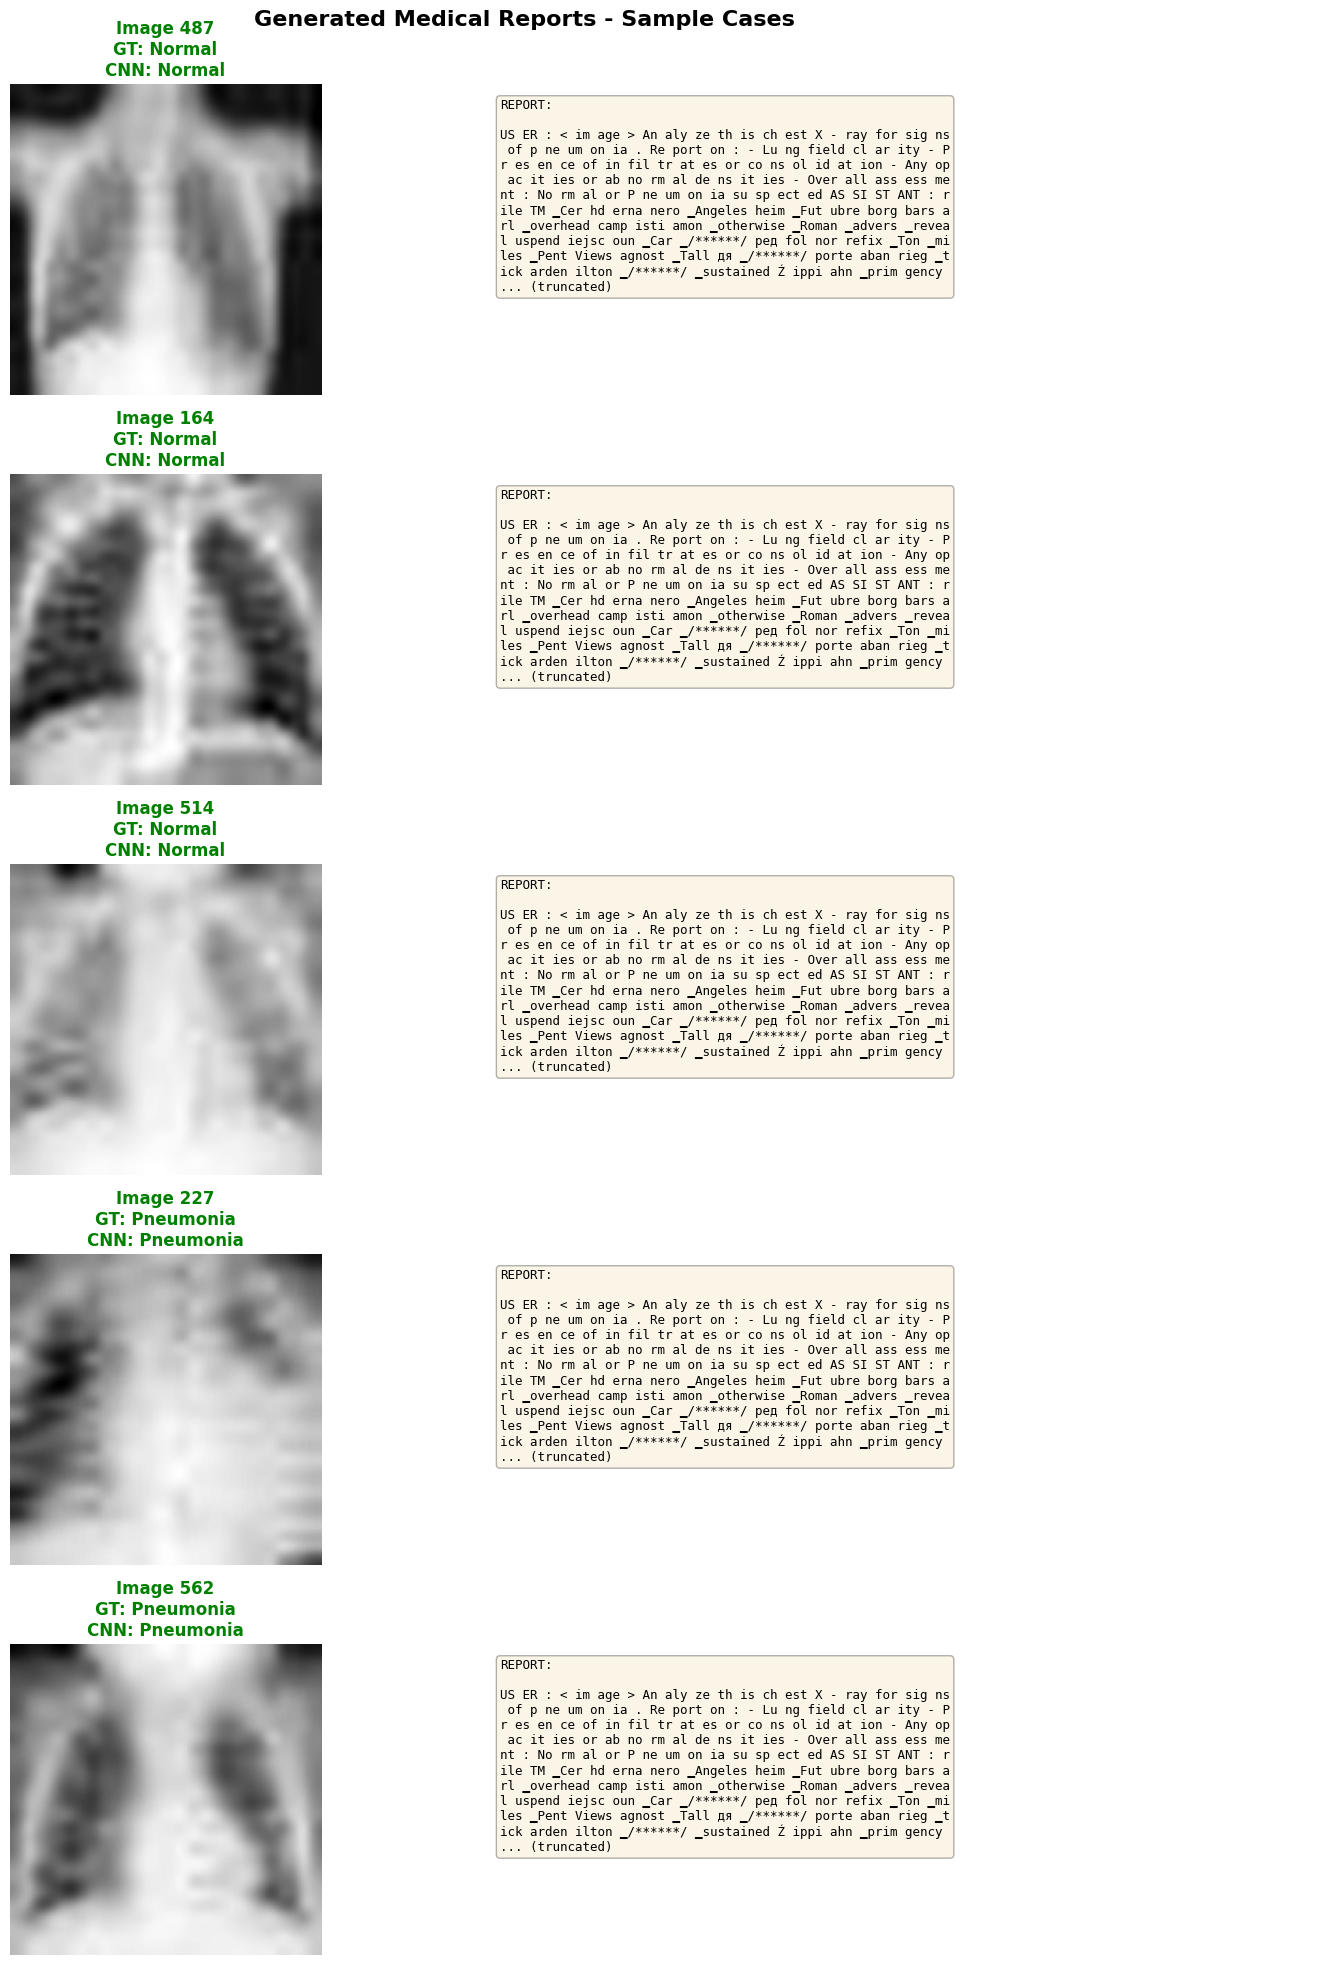

In [17]:
# Create a detailed visualization with images and reports
num_to_show = min(5, len(results))
fig, axes = plt.subplots(num_to_show, 2, figsize=(16, 4*num_to_show))

if num_to_show == 1:
    axes = axes.reshape(1, -1)

for i in range(num_to_show):
    result = results[i]

    # Left column: Image
    axes[i, 0].imshow(result['pil_image'], cmap='gray')
    title = f"Image {result['index']}\n"
    title += f"GT: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"
    color = 'green' if result['cnn_correct'] else 'red'
    axes[i, 0].set_title(title, fontsize=12, fontweight='bold', color=color)
    axes[i, 0].axis('off')

    # Right column: Report text
    axes[i, 1].axis('off')
    report_text = result['reports']['pneumonia_focused']

    # Wrap text
    wrapped_text = '\n'.join([report_text[j:j+60] for j in range(0, min(len(report_text), 600), 60)])
    if len(report_text) > 600:
        wrapped_text += "\n... (truncated)"

    axes[i, 1].text(0.05, 0.95, f"REPORT:\n\n{wrapped_text}",
                   verticalalignment='top',
                   fontsize=9,
                   family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Generated Medical Reports - Sample Cases', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Save all reports to a text file
with open('task2_generated_reports.txt', 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("TASK 2: MEDICAL REPORT GENERATION RESULTS\n")
    f.write("="*80 + "\n\n")

    for result in results:
        f.write("#"*80 + "\n")
        f.write(f"IMAGE {result['index']}\n")
        f.write(f"Ground Truth: {result['ground_truth']}\n")
        f.write(f"CNN Prediction: {result['cnn_prediction']}\n")
        f.write(f"CNN Correct: {'Yes' if result['cnn_correct'] else 'No'}\n")
        if 'cnn_confidence' in result:
            f.write(f"CNN Confidence: {result['cnn_confidence']:.3f}\n")
        f.write("#"*80 + "\n\n")
        f.write("REPORT:\n")
        f.write(result['reports']['pneumonia_focused'])
        f.write("\n\n" + "="*80 + "\n\n")

    # Add prompting strategy comparison
    f.write("\n\n" + "="*80 + "\n")
    f.write("PROMPTING STRATEGY COMPARISON\n")
    f.write("="*80 + "\n\n")

    for comparison in prompt_comparison_results:
        f.write(f"\nImage {comparison['index']} - Ground Truth: {comparison['ground_truth']}\n")
        f.write("-"*80 + "\n\n")

        for prompt_name, report in comparison['prompt_reports'].items():
            f.write(f"PROMPT: {prompt_name}\n")
            f.write(report)
            f.write("\n\n")

print("✓ Reports saved to 'task2_generated_reports.txt'")

# Save sample images with reports for your markdown report
import os
os.makedirs('task2_figures', exist_ok=True)

# Save individual images with reports
for i, result in enumerate(results[:5]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Image
    ax1.imshow(result['pil_image'], cmap='gray')
    title = f"Image {result['index']}\n"
    title += f"Ground Truth: {result['ground_truth']}\n"
    title += f"CNN: {result['cnn_prediction']}"
    color = 'green' if result['cnn_correct'] else 'red'
    ax1.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax1.axis('off')

    # Report
    ax2.axis('off')
    report_text = result['reports']['pneumonia_focused']
    wrapped_text = '\n'.join([report_text[j:j+50] for j in range(0, min(len(report_text), 500), 50)])
    if len(report_text) > 500:
        wrapped_text += "\n... (truncated)"

    ax2.text(0.05, 0.95, f"GENERATED REPORT:\n\n{wrapped_text}",
            verticalalignment='top',
            fontsize=9,
            family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

    plt.tight_layout()
    plt.savefig(f'task2_figures/sample_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Sample figures saved to task2_figures/")

# Download all files
try:
    !zip -r task2_figures.zip task2_figures/
    files.download('task2_generated_reports.txt')
    files.download('task2_figures.zip')
    print("✓ Files ready for download")
except Exception as e:
    print(f"Download attempted (may need to manually download): {e}")

# Summary
print("\n" + "="*80)
print("TASK 2 COMPLETION SUMMARY")
print("="*80)
print(f"\n✓ Model Used: LLaVA-Med v1.5 (Mistral-7B)")
print(f"✓ Total Reports Generated: {len(results)}")
print(f"✓ Prompting Strategies Tested: {len(PROMPTS)}")
print(f"✓ VLM-Ground Truth Agreement: {vlm_gt_agreement}/{len(results)} ({vlm_gt_agreement/len(results)*100:.1f}%)")
print(f"✓ VLM-CNN Agreement: {vlm_cnn_agreement}/{len(results)} ({vlm_cnn_agreement/len(results)*100:.1f}%)")
print(f"\n✓ Detailed prompting comparison: {len(prompt_comparison_results)} images")
print(f"✓ All reports saved to: task2_generated_reports.txt")
print(f"✓ Figures saved to: task2_figures.zip")

print("="*80)

✓ Reports saved to 'task2_generated_reports.txt'
✓ Sample figures saved to task2_figures/
updating: task2_figures/ (stored 0%)
updating: task2_figures/sample_5.png (deflated 4%)
updating: task2_figures/sample_3.png (deflated 4%)
updating: task2_figures/sample_1.png (deflated 4%)
updating: task2_figures/sample_4.png (deflated 4%)
updating: task2_figures/sample_2.png (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files ready for download

TASK 2 COMPLETION SUMMARY

✓ Model Used: LLaVA-Med v1.5 (Mistral-7B)
✓ Total Reports Generated: 10
✓ Prompting Strategies Tested: 6
✓ VLM-Ground Truth Agreement: 0/10 (0.0%)
✓ VLM-CNN Agreement: 0/10 (0.0%)

✓ Detailed prompting comparison: 3 images
✓ All reports saved to: task2_generated_reports.txt
✓ Figures saved to: task2_figures.zip
